This notebook calculates viscosity of Type I and II microemulsions and IFT between ME and excess phase

In [93]:
import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import MolWt
import numpy as np
from functions_for_surfactants import HLD_calculation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets 
from itertools import product
from functions_for_surfactants import draw_tubes_volumes, xi_calculation, len_calculation
from sympy import symbols, solve
Ld, Rd = symbols('Ld Rd')

**Enter parameters of the surfactant**

Enter SMILES of your surfactant CCCCCCCCCCCC[N+](C)(C)C


Molecular weiight of the molecule is 228.44399999999996
Tail length is 21.684 Å


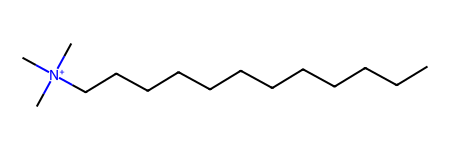

In [4]:
smi = input('Enter SMILES of your surfactant')
mol = Chem.MolFromSmiles(smi)

L = len_calculation(mol)
MWt = MolWt(mol)
print('Molecular weiight of the molecule is {}'.format(MWt))
print('Tail length is {} Å'.format(L))

mol

In [6]:
surfactant_selection = widgets.Dropdown(options = ['', 'Ionic', 'Nonionic'], value = '')
surfactant_selection

Dropdown(options=('', 'Ionic', 'Nonionic'), value='')

In [49]:
if surfactant_selection.value == 'Ionic':
    coeff = 1
else:
    coeff = 4

Enter weight concentration

In [10]:
wt_concentration = (float(input('Enter weight concentrationof the surfactant')))
mol_concentration = ((1000 * wt_concentration / 100)/MWt)/1000

Enter weight concentrationof the surfactant 5


Calculate $\xi$ here 

In [12]:
MWt_oil = float(input('Molecular weight of the oil'))
density = float(input('Density of the oil, g/cc'))
interfacial_area = float(input(r'Interfacial area Å2'))
xi = xi_calculation(L, interfacial_area, density, MWt_oil, surfactant_type=surfactant_selection.value)
print('Automatically calculated ξ is {}'.format(xi))

Molecular weight of the oil 104
Density of the oil, g/cc 0.76
Interfacial area Å2 45


Automatically calculated ξ is 172.02169522369732


Type in ξ manually, if you don't want automatic calculations

In [17]:
xi = float(input('Your manual value of ξ'))
interfacial_area = float(input(r'Interfacial area Å2'))

Your manual value of ξ 452
Interfacial area Å2 68


Enter volumes of water and oil

In [14]:
Vw = (float(input('Enter volume of water, mL ')))
Vo = (float(input('Enter volume of oil, mL ')))
Vs = (wt_concentration/100)*Vw

As =  Vw*mol_concentration*6E23*interfacial_area/1E24  
Rw_ref = 3*Vw/As
Ro_ref = 3*Vo/As

Enter volume of water, mL  5
Enter volume of oil, mL  5


**Enter HLD parameters**

In [16]:
variable_selection = widgets.Dropdown(options = ['', 'Cc', 'EACN', 'Salinity', 'Temperature'], value = '')
variable_selection

Dropdown(options=('', 'Cc', 'EACN', 'Salinity', 'Temperature'), value='')

In [18]:
varied_value = (float(input('Enter first range value of {}'.format(variable_selection.value))), 
                float(input('Enter end range value of {}'.format(variable_selection.value))))
varied_value_range = np.linspace(varied_value[0], varied_value[1], 20)

Enter first range value of Salinity 1
Enter end range value of Salinity 10


In [20]:
if variable_selection.value == 'EACN':
    Cc = float(input('Enter Cc value'))
    Sal = float(input('Enter salinity value'))
    Temp = float(input('Enter temperature value'))
elif variable_selection.value == 'Cc':
    EACN = float(input('Enter EACN value'))
    Sal = float(input('Enter salinity value'))
    Temp = float(input('Enter temperature value'))
elif variable_selection.value == 'Temperature':
    Cc = float(input('Enter Cc value'))
    Sal = float(input('Enter salinity value'))
    EACN = float(input('Enter EACN value'))
elif variable_selection.value == 'Salinity':
    Cc = float(input('Enter Cc value'))
    Temp = float(input('Enter temperature'))
    EACN = float(input('Enter EACN value'))

Enter Cc value -0.5
Enter temperature 25
Enter EACN value 8


In [22]:
if variable_selection.value == 'EACN':
    HLDs = HLD_calculation(EACN = varied_value_range, Cc = Cc, Sal = Sal, Temp = Temp, Type = surfactant_selection.value)
elif variable_selection.value == 'Cc':
    HLDs = HLD_calculation(EACN = EACN, Cc = varied_value_range, Sal = Sal, Temp = Temp, Type = surfactant_selection.value)
elif variable_selection.value == 'Temperature':
    HLDs = HLD_calculation(EACN = EACN, Cc = Cc, Sal = Sal, Temp = varied_value_range, Type = surfactant_selection.value)
elif variable_selection.value == 'Salinity':
    HLDs = HLD_calculation(EACN = EACN, Cc = Cc, Sal = varied_value_range, Temp = Temp, Type = surfactant_selection.value)

**Calculation of relative volume of phases and microemulsion types**

In [24]:
#calculation of NACs and emulsion types
Hs = -(HLDs/L)
Ros = np.zeros((len(Hs)), dtype = 'float')
Rws = np.zeros((len(Hs)), dtype = 'float')


for i,H in enumerate(Hs):
    if H > 0:
        Rw = Rw_ref
        Ro = 1/(H+1/Rw)
    else:
        Ro = Ro_ref
        Rw = 1/(np.abs(H)+1/Ro)
    Ros[i] = Ro
    Rws[i] = Rw

NACs = 0.5*((1/Ros)+(1/Rws))
NACs_bin = (Ros > Rws).astype(int)
NACs_bin[NACs<1/xi] = 2

Rs = np.zeros(20)
for i in range(20):
    if Ros[i] < Rws[i]:
        Rs[i] = Ros[i]
    else:
        Rs[i] = Rws[i]

**IFT calculation**

We transform temperature into absolute value, depending on if it is fized or vaied value in HLD equation  

In [28]:
if variable_selection.value == 'Temperature':
    T = varied_value_range+273
else:
    T = Temp + 273
    
kb = 1.38E-23
kbT = kb*T

Calculating and plotting IFT value

In [74]:
IFTome = coeff*kbT/(4*3.14*((Ros*1E-10)**2))
IFTwme = coeff*kbT/(4*3.14*((Rws*1E-10)**2))

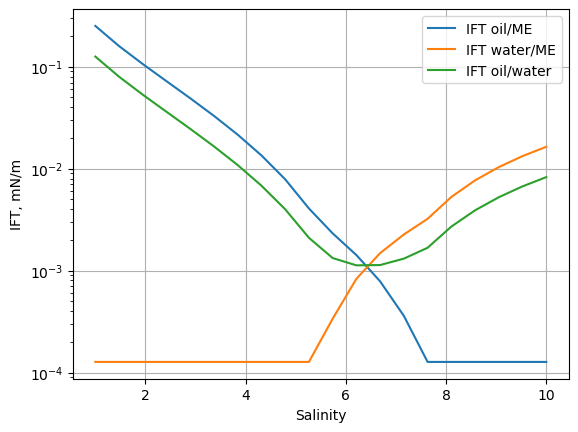

In [81]:
plt.plot(varied_value_range, IFTome*1000, label = 'IFT oil/ME')
plt.plot(varied_value_range, IFTwme*1000, label = 'IFT water/ME')
plt.plot(varied_value_range, 500*(IFTome+IFTwme), label  = 'IFT oil/water')

plt.yscale('log')
plt.grid(visible = True)
plt.xlabel(variable_selection.value)
plt.ylabel('IFT, mN/m')
plt.legend()

**Viscosity calculation**

In [34]:
mask = NACs_bin==2
Rome  = Ros
Rwme = Rws

Rwme[mask] = 1/((HLDs[mask]/(2*L))+1/xi)
Rome[mask] = 1/(1/Rwme[mask] - (HLDs[mask]/L))
Vome = Rome*As/3
Vwme = Rwme*As/3
Vtot = Vome + Vwme
#change viscosity here!
mu_water = 1
mu_oil = 1
phio = np.zeros(20)
phiw = np.zeros(20)

for i in range(20):
    if HLDs[i] < 0:
        phio[i] = Vome[i]/Vtot[i]
        phiw[i] = 1 - phio[i]
    else:
        phiw[i] = Vwme[i]/Vtot[i]
        phio[i] = 1 - phiw[i]

In [36]:
mask_I = NACs_bin == 0
mask_II = NACs_bin == 1

viscosities_I = mu_water*(1+2.5*phio[mask_I])
viscosities_II = mu_oil*(1+2.5*phiw[mask_II])

In [40]:
viscosities_I = np.zeros(sum(mask_I))
viscosities_II = np.zeros(sum(mask_II))

for i, (Ha, NAC) in enumerate(zip(Hs[mask_I], NACs[mask_I])):
    #calculation of Ld, Rd - radius of globules in ME, solving simultaneously two equations for NAC and Hs
    system = [2/(Ld+2*Rd) + (Ld/Rd)*(1/(2*Ld+4*Rd)) - Ha/2, (2*Ld + 4 * Rd)/(3*Ld*Rd + (4 * Rd**2)) - NAC]
    solution = solve(system, Ld, Rd)
    for tup in solution:
        #solution may have negative values
        if (tup[0]>0) & (tup[1] > 0):
            Ld, Rd = tup
    #ME viscosity calculation
    mu = mu_water*(1+(4*phio[mask_I][i]*(Ld**2)/(3.14*1*((2*Rd)**2))))
    viscosities_I[i] = mu


for i, (Ha, NAC) in enumerate(zip(Hs[mask_II], NACs[mask_II])):
    system = [2/(Ld+2*Rd) + (Ld/Rd)*(1/(2*Ld+4*Rd)) - Ha/2, (2*Ld + 4 * Rd)/(3*Ld*Rd + (4 * Rd**2)) - NAC]
    solution = solve(system, Ld, Rd)
    for tup in solution:
        if (tup[0]>0) & (tup[1] > 0):
            Ld, Rd = tup
    mu = mu_water*(1+(4*phio[mask_II][i]*(Ld**2)/(3.14*1*((2*Rd)**2))))
    viscosities_II[i] = mu
    

In [ ]:
#plotting

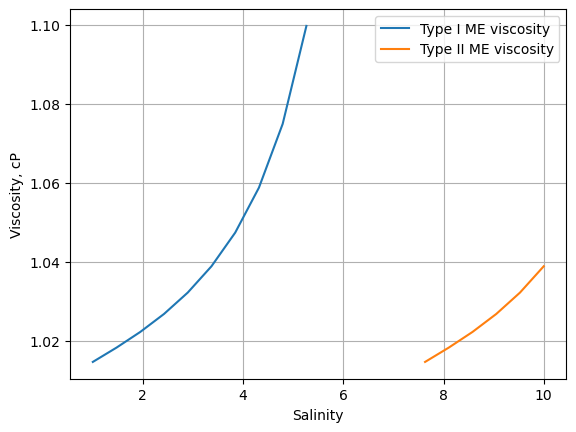

In [61]:
plt.plot(varied_value_range[mask_I], viscosities_I, label = 'Type I ME viscosity')
plt.plot(varied_value_range[mask_II], viscosities_II, label = 'Type II ME viscosity')
plt.ylabel('Viscosity, cP')
plt.xlabel(variable_selection.value)
plt.legend()
plt.grid(visible = True)